# Energy-TTM Day-Ahead Zone Demand Forecasting and Demand Response Analysis

This notebook converts the supplied **2025 one-minute dataset** to hourly resolution, runs
leakage-free rolling D+1 backtests with the pretrained **EnergyFM Energy-TTM**, compares it
with 24-hour and 168-hour persistence baselines, detects demand peaks, and evaluates
interpretable Demand Response (DR) candidates.

`1-minute data → hourly aggregation → Energy-TTM → rolling D+1 forecasts → peaks → DR candidates → labels + metrics + figures`

Two labels are kept strictly separate:

- `is_dr_peak`: observed high-demand/peak condition; used to evaluate peak detection.
- `is_dr_event`: observed DR intervention/event; used to evaluate DR candidates.

Energy-TTM forecasts load. It is **not** treated as a DR classifier.

## 1. Configuration

In [1]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
DATA_PATH = PROJECT_ROOT / "data" / "dr_dataset_2025_1min_v2.csv"
ZIP_PATH = PROJECT_ROOT / "data" / "dr_dataset_2025_1min_v2.zip"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RESAMPLE_FREQ = "1h"
FORECAST_HORIZON = 24
BACKTEST_DAYS = None  # None = every eligible day after the required 168-hour context
PRESENTATION_DAY = None  # None = last backtested day containing a peak or DR-event label
PEAK_PERCENTILE = 0.95
DYNAMIC_K = 2.0
DYNAMIC_WINDOW_HOURS = 168
WARNING_MULTIPLIER = 1.10
DR_GAP_PERCENTILE = 0.10
DR_RATIO_PERCENTILE = 0.90
MAX_INTERPOLATION_HOURS = 3
RANDOM_SEED = 42

MODEL_ID = "EnergyFM/energy-ttm"
MODEL_REVISION = "main"
FIGURE_DPI = 300
FIGSIZE = (12, 5.5)

print("Input:", DATA_PATH)
print("Output directory:", OUTPUT_DIR.resolve())

Input: C:\Users\moham\Desktop\demand response\demand_response_project\data\dr_dataset_2025_1min_v2.csv
Output directory: C:\Users\moham\Desktop\demand response\demand_response_project\outputs


## 2. Imports

In [2]:
import logging
import os
import random
import shutil
import warnings
import zipfile

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import torch
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, average_precision_score, confusion_matrix,
    f1_score, mean_absolute_error, mean_squared_error, precision_score, r2_score,
    recall_score, roc_auc_score,
)
from tsfm_public.models.tinytimemixer import TinyTimeMixerForPrediction

os.environ.setdefault("HF_HUB_DISABLE_SYMLINKS_WARNING", "1")
warnings.filterwarnings("ignore", category=FutureWarning)
logging.getLogger("tsfm_public.models.tinytimemixer.modeling_tinytimemixer").setLevel(logging.ERROR)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

plt.style.use("seaborn-v0_8-whitegrid")
COLORS = {"actual":"#1F4E79", "pred":"#E67E22", "peak":"#C1121F", "event":"#7B2CBF",
          "production":"#2A9D8F", "pv":"#F4A261", "baseline24":"#6C757D", "baseline168":"#8D99AE"}

def save_show(fig, filename):
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / filename, dpi=FIGURE_DPI, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close(fig)

Using device: cpu


## 3. Dataset loading

In [3]:
if not DATA_PATH.exists():
    if not ZIP_PATH.exists():
        raise FileNotFoundError(f"Neither {DATA_PATH} nor {ZIP_PATH} exists.")
    with zipfile.ZipFile(ZIP_PATH) as archive:
        matches = [name for name in archive.namelist() if Path(name).name == DATA_PATH.name]
        if not matches:
            raise FileNotFoundError(f"{DATA_PATH.name} is not present in {ZIP_PATH}.")
        DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
        with archive.open(matches[0]) as source_file, DATA_PATH.open("wb") as target_file:
            shutil.copyfileobj(source_file, target_file)
        print("Extracted:", DATA_PATH)

df = pd.read_csv(DATA_PATH)
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
print(df.head())

            timestamp client_id region_id  aggregate_power_w  ac_power_w  \
0 2025-01-01 00:00:00      C001       TUN               78.0         4.0   
1 2025-01-01 00:01:00      C001       TUN               66.0         4.0   
2 2025-01-01 00:02:00      C001       TUN               72.0         1.0   
3 2025-01-01 00:03:00      C001       TUN               58.0         5.0   
4 2025-01-01 00:04:00      C001       TUN               65.0         2.0   

   water_heater_power_w  washing_machine_power_w  temperature_c  is_holiday  \
0                   3.0                      0.0           10.2           1   
1                   0.0                      0.0           10.2           1   
2                   1.0                      1.0           10.2           1   
3                   0.0                      0.0           10.2           1   
4                   0.0                      1.0           10.2           1   

   is_ramadan  is_dr_event  zone_consumption_mw  steg_production_mw 

## 4. Dataset inspection

In [4]:
EXPECTED_COLUMNS = [
    "timestamp", "client_id", "region_id", "aggregate_power_w", "ac_power_w",
    "water_heater_power_w", "washing_machine_power_w", "temperature_c", "is_holiday",
    "is_ramadan", "is_dr_event", "zone_consumption_mw", "steg_production_mw",
    "pv_production_mw", "is_dr_peak",
]
missing_columns = sorted(set(EXPECTED_COLUMNS) - set(df.columns))
if missing_columns:
    raise ValueError(f"Dataset is missing required columns: {missing_columns}")

continuous_columns = [
    "aggregate_power_w", "ac_power_w", "water_heater_power_w",
    "washing_machine_power_w", "temperature_c", "zone_consumption_mw",
    "steg_production_mw", "pv_production_mw",
]
binary_columns = ["is_holiday", "is_ramadan", "is_dr_event", "is_dr_peak"]

print("Shape:", df.shape)
print("Date range:", df["timestamp"].min(), "→", df["timestamp"].max())
print("Clients:", df["client_id"].nunique())
print("Regions:", df["region_id"].nunique())
print("Duplicate timestamps:", df["timestamp"].duplicated().sum())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isna().sum())
display(df[continuous_columns].describe().T)
for column in binary_columns:
    print(f"\n{column} counts:\n{df[column].value_counts(dropna=False).sort_index()}")

Shape: (525600, 15)
Date range: 2025-01-01 00:00:00 → 2025-12-31 23:59:00
Clients: 1
Regions: 1
Duplicate timestamps: 0

Data types:
 timestamp                  datetime64[ns]
client_id                          object
region_id                          object
aggregate_power_w                 float64
ac_power_w                        float64
water_heater_power_w              float64
washing_machine_power_w           float64
temperature_c                     float64
is_holiday                          int64
is_ramadan                          int64
is_dr_event                         int64
zone_consumption_mw               float64
steg_production_mw                float64
pv_production_mw                  float64
is_dr_peak                        float64
dtype: object

Missing values:
 timestamp                     0
client_id                     0
region_id                     0
aggregate_power_w          1739
ac_power_w                 2164
water_heater_power_w       1037
washing_mach

,count,mean,std,min,25%,50%,75%,max
aggregate_power_w,523861.0,503.689471,743.167568,0.0,65.0,166.0,439.0,10332.0
ac_power_w,523436.0,109.980873,343.159940,0.0,2.0,3.0,5.0,1590.0
water_heater_power_w,524563.0,147.749860,439.145292,0.0,0.0,0.0,2.0,1573.0
washing_machine_power_w,521202.0,13.176929,125.006009,0.0,0.0,0.0,2.0,4134.0
temperature_c,523320.0,19.176947,7.519779,1.2,13.4,18.7,24.4,43.8
zone_consumption_mw,525323.0,663.264392,131.380534,407.7,549.3,656.0,749.4,1292.2
steg_production_mw,525600.0,984.477643,51.899094,774.7,978.4,1012.4,1016.0,1029.1
pv_production_mw,525449.0,49.220682,67.657325,0.0,0.0,0.0,91.8,247.8



is_holiday counts:
is_holiday
0    504000
1     21600
Name: count, dtype: int64

is_ramadan counts:
is_ramadan
0    483840
1     41760
Name: count, dtype: int64

is_dr_event counts:
is_dr_event
0    521400
1      4200
Name: count, dtype: int64

is_dr_peak counts:
is_dr_peak
0.0    518520
1.0      6653
NaN       427
Name: count, dtype: int64


## 5. Data cleaning

`aggregate_power_w` is client/household consumption. `zone_consumption_mw` is wider
zone/grid demand and is the Energy-TTM target because peak and DR analysis concern system demand.
`steg_production_mw` and `pv_production_mw` describe supply adequacy. They are used for
historical analysis; D+1 rules use a **24-hour persistence production forecast**, not actual
future production.

In [5]:
raw_rows = len(df)
df = df.dropna(subset=["timestamp"]).sort_values("timestamp")
duplicate_rows = int(df.duplicated(subset=["timestamp", "client_id"], keep="last").sum())
df = df.drop_duplicates(subset=["timestamp", "client_id"], keep="last")
for column in continuous_columns + binary_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

print(f"Rows retained: {len(df):,}/{raw_rows:,}")
print("Duplicate timestamp/client rows removed:", duplicate_rows)
print("Monotonic timestamp:", df["timestamp"].is_monotonic_increasing)

Rows retained: 525,600/525,600
Duplicate timestamp/client rows removed: 0
Monotonic timestamp: True


## 6. One-minute → hourly aggregation

Continuous power, demand, production, and temperature columns use the hourly **mean**.
Binary/calendar/event columns use hourly **maximum**: if the condition occurs at least once,
the hour is labelled 1. Limited time interpolation repairs short sensor gaps only.

In [6]:
aggregation = {column: "mean" for column in continuous_columns}
aggregation.update({column: "max" for column in binary_columns})
hourly = df.set_index("timestamp").resample(RESAMPLE_FREQ).agg(aggregation)

missing_before = hourly.isna().sum()
hourly[continuous_columns] = hourly[continuous_columns].interpolate(
    method="time", limit=MAX_INTERPOLATION_HOURS, limit_area="inside"
)
hourly[binary_columns] = hourly[binary_columns].fillna(0).astype(int)

if hourly["zone_consumption_mw"].isna().any():
    raise ValueError("Unresolved hourly zone-consumption gaps remain after limited interpolation.")

print("Hourly shape:", hourly.shape)
print("Hourly range:", hourly.index.min(), "→", hourly.index.max())
print("Missing hourly values before interpolation:\n", missing_before[missing_before.gt(0)])
print("Missing hourly values after preparation:", int(hourly.isna().sum().sum()))

hourly_relationship = pd.crosstab(
    hourly["is_dr_peak"], hourly["is_dr_event"],
    rownames=["is_dr_peak"], colnames=["is_dr_event"], dropna=False,
).reindex(index=[0,1], columns=[0,1], fill_value=0)
peak_hours_all = int(hourly["is_dr_peak"].sum())
event_hours_all = int(hourly["is_dr_event"].sum())
overlap_hours = int(((hourly["is_dr_peak"] == 1) & (hourly["is_dr_event"] == 1)).sum())
print("\nPeak/event cross-tabulation:")
display(hourly_relationship)
print("DR peak hours:", peak_hours_all)
print("DR event hours:", event_hours_all)
print("% peak hours associated with DR events:", f"{100*overlap_hours/max(peak_hours_all,1):.2f}%")
print("% DR event hours occurring during peaks:", f"{100*overlap_hours/max(event_hours_all,1):.2f}%")

Hourly shape: (8760, 12)
Hourly range: 2025-01-01 00:00:00 → 2025-12-31 23:00:00
Missing hourly values before interpolation:
 aggregate_power_w          11
ac_power_w                 24
water_heater_power_w        6
washing_machine_power_w    64
temperature_c              38
dtype: int64
Missing hourly values after preparation: 85

Peak/event cross-tabulation:


is_dr_event,0,1
is_dr_peak,,
0,8589,19
1,101,51


DR peak hours: 152
DR event hours: 70
% peak hours associated with DR events: 33.55%
% DR event hours occurring during peaks: 72.86%


## 7. Exploratory analysis

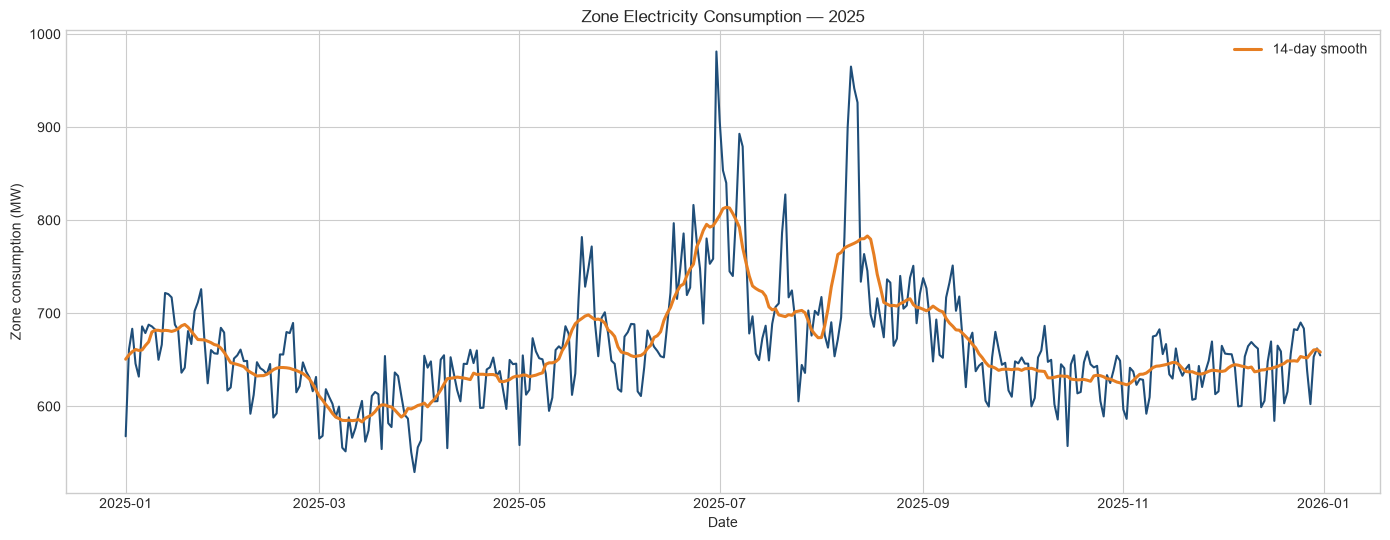

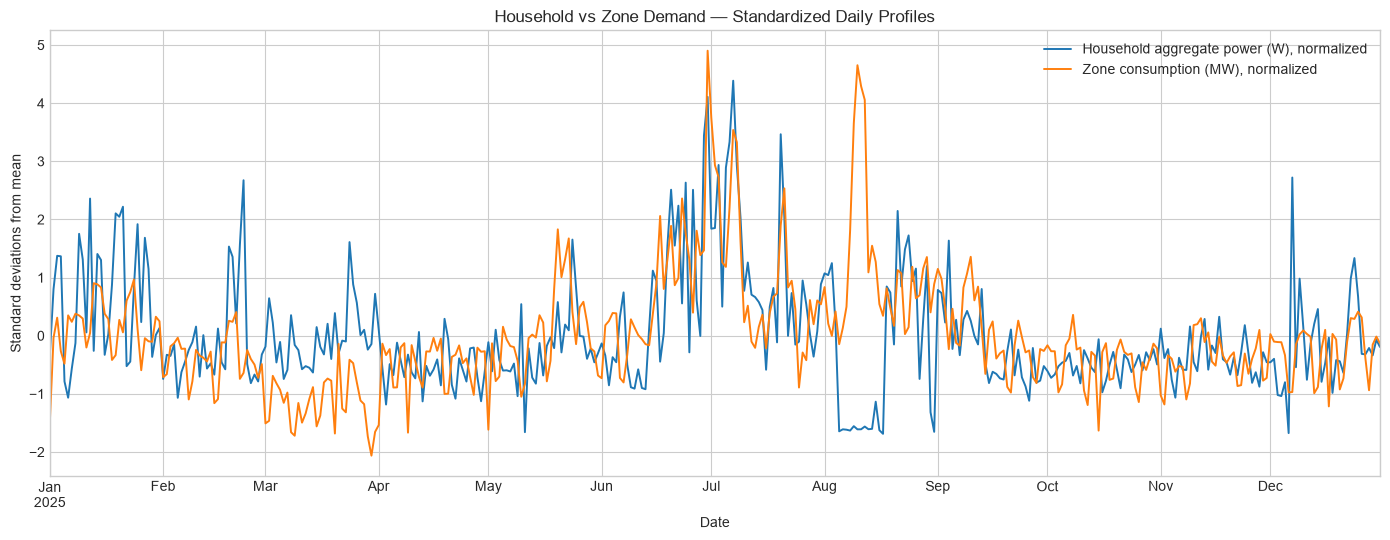

In [7]:
# Graph 1 — readable full-year daily mean zone demand
daily_zone = hourly["zone_consumption_mw"].resample("1D").mean()
fig, ax = plt.subplots(figsize=(14,5.5))
ax.plot(daily_zone.index, daily_zone, color=COLORS["actual"], linewidth=1.5)
ax.plot(daily_zone.index, daily_zone.rolling(14, center=True, min_periods=1).mean(), color=COLORS["pred"], linewidth=2.2, label="14-day smooth")
ax.set(title="Zone Electricity Consumption — 2025", xlabel="Date", ylabel="Zone consumption (MW)")
ax.legend()
save_show(fig, "full_year_demand.png")

# Graph 2 — normalized household and zone demand (different physical units)
daily_household = hourly["aggregate_power_w"].resample("1D").mean()
normalized = pd.DataFrame({
    "Household aggregate power (W), normalized": (daily_household-daily_household.mean())/daily_household.std(),
    "Zone consumption (MW), normalized": (daily_zone-daily_zone.mean())/daily_zone.std(),
})
fig, ax = plt.subplots(figsize=(14,5.5))
normalized.plot(ax=ax, linewidth=1.4)
ax.set(title="Household vs Zone Demand — Standardized Daily Profiles", xlabel="Date", ylabel="Standard deviations from mean")
save_show(fig, "household_vs_zone.png")

## 8. Feature engineering

In [8]:
hourly["hour"] = hourly.index.hour
hourly["day_of_week"] = hourly.index.dayofweek
hourly["day_of_month"] = hourly.index.day
hourly["month"] = hourly.index.month
hourly["day_of_year"] = hourly.index.dayofyear
hourly["is_weekend"] = (hourly["day_of_week"] >= 5).astype(int)

hourly["production_total_mw"] = hourly["steg_production_mw"] + hourly["pv_production_mw"]
hourly["supply_demand_gap_mw"] = hourly["production_total_mw"] - hourly["zone_consumption_mw"]
safe_production = hourly["production_total_mw"].replace(0, np.nan)
hourly["demand_supply_ratio"] = hourly["zone_consumption_mw"] / safe_production
hourly["pv_share"] = hourly["pv_production_mw"] / safe_production

for lag in (1, 24, 48, 168):
    hourly[f"load_lag_{lag}h"] = hourly["zone_consumption_mw"].shift(lag)
for window in (24, 168):
    shifted = hourly["zone_consumption_mw"].shift(1)
    hourly[f"rolling_mean_{window}h"] = shifted.rolling(window).mean()
    hourly[f"rolling_std_{window}h"] = shifted.rolling(window).std()

print("Feature columns created:")
print([column for column in hourly.columns if "lag" in column or "rolling" in column or column in {
    "production_total_mw", "supply_demand_gap_mw", "demand_supply_ratio", "pv_share"
}])

Feature columns created:
['production_total_mw', 'supply_demand_gap_mw', 'demand_supply_ratio', 'pv_share', 'load_lag_1h', 'load_lag_24h', 'load_lag_48h', 'load_lag_168h', 'rolling_mean_24h', 'rolling_std_24h', 'rolling_mean_168h', 'rolling_std_168h']


## 9. Energy-TTM loading

The official `EnergyFM/energy-ttm` checkpoint uses `TinyTimeMixerForPrediction`, input shape
`[batch, context, channel]`, 168 hourly context points, and a 24-hour prediction horizon.
No explicit frequency token is required by this checkpoint. The local cache is preferred;
the Hugging Face Hub is used automatically on the first run.

In [9]:
model_kwargs = {"revision": MODEL_REVISION, "num_input_channels": 1}
try:
    model = TinyTimeMixerForPrediction.from_pretrained(MODEL_ID, local_files_only=True, **model_kwargs)
    model_source = "local Hugging Face cache"
except OSError:
    model = TinyTimeMixerForPrediction.from_pretrained(MODEL_ID, **model_kwargs)
    model_source = "Hugging Face Hub"
model = model.to(device).eval()
context_length = int(model.config.context_length)
prediction_length = int(model.config.prediction_length)
print(f"Loaded {MODEL_ID} from {model_source}")
print("Context length:", context_length, "hours")
print("Prediction length:", prediction_length, "hours")
if prediction_length < FORECAST_HORIZON:
    raise ValueError("Selected checkpoint cannot produce the required 24-hour horizon.")

Loaded EnergyFM/energy-ttm from local Hugging Face cache
Context length: 168 hours
Prediction length: 24 hours


## 10. Leakage-free D+1 forecasting

In [10]:
def energy_ttm_forecast(history_series):
    context = history_series.tail(context_length)
    expected = pd.date_range(context.index[-1] - pd.Timedelta(context_length-1, unit="h"), periods=context_length, freq="1h")
    if len(context) != context_length or not context.index.equals(expected) or context.isna().any():
        raise ValueError("Energy-TTM requires 168 consecutive, non-missing hourly context values.")
    values = context.to_numpy(dtype=np.float32)
    mean, std = float(values.mean()), float(values.std(ddof=0))
    if std < 1e-8:
        raise ValueError("Context variance is too small for standardization.")
    tensor = torch.tensor((values-mean)/(std+1e-8), dtype=torch.float32, device=device).reshape(1,context_length,1)
    with torch.inference_mode():
        scaled = model(tensor).prediction_outputs[0,:FORECAST_HORIZON,0].detach().cpu().numpy()
    return np.clip(scaled*(std+1e-8)+mean, 0, None)

complete_days = hourly["zone_consumption_mw"].notna().groupby(hourly.index.normalize()).sum()
eligible_days = complete_days[complete_days.eq(24)].index
eligible_days = eligible_days[eligible_days >= hourly.index.min().normalize() + pd.Timedelta(context_length//24, unit="D")]
backtest_days = pd.DatetimeIndex(eligible_days if BACKTEST_DAYS is None else eligible_days[-BACKTEST_DAYS:])
daily_labels = hourly[["is_dr_peak","is_dr_event"]].groupby(hourly.index.normalize()).max().max(axis=1)
labeled_backtest_days = backtest_days[backtest_days.isin(daily_labels[daily_labels.eq(1)].index)]
presentation_day = (
    pd.Timestamp(PRESENTATION_DAY).normalize() if PRESENTATION_DAY is not None
    else labeled_backtest_days[-1] if len(labeled_backtest_days) else backtest_days[-1]
)
if presentation_day not in backtest_days:
    raise ValueError("PRESENTATION_DAY must be one of the rolling backtest days.")
print(f"Backtest origins: {backtest_days[0].date()} → {backtest_days[-1].date()} ({len(backtest_days)} days)")
print("Presentation/evaluation day for 24-hour figures:", presentation_day.date())

Backtest origins: 2025-01-08 → 2025-12-31 (358 days)
Presentation/evaluation day for 24-hour figures: 2025-11-14


## 11. Rolling backtesting

In [11]:
backtest_frames = []
for day in backtest_days:
    history = hourly.loc[hourly.index < day]
    forecast_index = pd.date_range(day, periods=FORECAST_HORIZON, freq="1h")
    future = hourly.reindex(forecast_index)
    prediction = energy_ttm_forecast(history["zone_consumption_mw"])

    percentile_threshold = float(history["zone_consumption_mw"].quantile(PEAK_PERCENTILE))
    dynamic_history = history["zone_consumption_mw"].tail(DYNAMIC_WINDOW_HOURS)
    dynamic_threshold = float(dynamic_history.mean() + DYNAMIC_K*dynamic_history.std(ddof=1))
    gap_threshold = float(history["supply_demand_gap_mw"].quantile(DR_GAP_PERCENTILE))
    ratio_threshold = float(history["demand_supply_ratio"].quantile(DR_RATIO_PERCENTILE))
    hourly_event_rate = history.groupby("hour")["is_dr_event"].mean().reindex(range(24), fill_value=0)
    event_rate_cutoff = max(float(hourly_event_rate.quantile(0.75)), float(history["is_dr_event"].mean()))

    # Legitimate D+1 supply estimate: yesterday's corresponding production, never D+1 actual supply.
    production_forecast = hourly["production_total_mw"].reindex(forecast_index-pd.Timedelta(24, unit="h")).to_numpy()
    predicted_gap = production_forecast - prediction
    predicted_ratio = np.divide(prediction, production_forecast, out=np.full(24,np.nan), where=production_forecast>0)
    peak_pct = (prediction >= percentile_threshold).astype(int)
    peak_dyn = (prediction >= dynamic_threshold).astype(int)
    high_risk_hour = np.array([hourly_event_rate.loc[t.hour] >= event_rate_cutoff for t in forecast_index], dtype=int)
    supply_risk = ((predicted_gap <= gap_threshold) | (predicted_ratio >= ratio_threshold)).astype(int)
    known_calendar_risk = ((future["is_holiday"].to_numpy()==1) | (future["is_ramadan"].to_numpy()==1)).astype(int)
    dr_risk_score = 2*peak_pct + peak_dyn + supply_risk + high_risk_hour + known_calendar_risk
    dr_candidate = ((peak_pct==1) & (dr_risk_score>=3)).astype(int)

    frame = pd.DataFrame({
        "forecast_day": day, "timestamp": forecast_index,
        "actual_zone_load_mw": future["zone_consumption_mw"].to_numpy(),
        "predicted_zone_load_mw": prediction,
        "persistence_24h_mw": hourly["zone_consumption_mw"].reindex(forecast_index-pd.Timedelta(24,unit="h")).to_numpy(),
        "persistence_168h_mw": hourly["zone_consumption_mw"].reindex(forecast_index-pd.Timedelta(168,unit="h")).to_numpy(),
        "peak_threshold_mw": percentile_threshold, "dynamic_threshold_mw": dynamic_threshold,
        "predicted_peak": peak_pct, "predicted_peak_dynamic": peak_dyn,
        "actual_dr_peak": future["is_dr_peak"].to_numpy(dtype=int),
        "production_forecast_mw": production_forecast, "predicted_supply_demand_gap_mw": predicted_gap,
        "predicted_demand_supply_ratio": predicted_ratio, "dr_risk_score": dr_risk_score,
        "dr_candidate": dr_candidate, "actual_dr_event": future["is_dr_event"].to_numpy(dtype=int),
    })
    frame["forecast_error_mw"] = frame["actual_zone_load_mw"]-frame["predicted_zone_load_mw"]
    frame["severity"] = np.select(
        [frame["predicted_zone_load_mw"]<percentile_threshold,
         frame["predicted_zone_load_mw"]<percentile_threshold*WARNING_MULTIPLIER],
        ["Normal","Warning"], default="Critical")
    backtest_frames.append(frame)

backtest_results = pd.concat(backtest_frames, ignore_index=True)
d1_forecast = backtest_results.loc[backtest_results["forecast_day"].eq(presentation_day)].copy()
print("Backtest rows:", len(backtest_results))
display(d1_forecast.head())

Backtest rows: 8592


,forecast_day,timestamp,actual_zone_load_mw,predicted_zone_load_mw,persistence_24h_mw,persistence_168h_mw,peak_threshold_mw,dynamic_threshold_mw,predicted_peak,predicted_peak_dynamic,actual_dr_peak,production_forecast_mw,predicted_supply_demand_gap_mw,predicted_demand_supply_ratio,dr_risk_score,dr_candidate,actual_dr_event,forecast_error_mw,severity
7440,2025-11-14,2025-11-14 00:00:00,518.570000,536.757141,523.378333,489.891667,901.1165,841.87574,0,0,0,886.506667,349.749526,0.605474,0,0,0,-18.187141,Normal
7441,2025-11-14,2025-11-14 01:00:00,519.368333,522.952820,522.625000,492.863333,901.1165,841.87574,0,0,0,886.953333,364.000514,0.589606,0,0,0,-3.584486,Normal
7442,2025-11-14,2025-11-14 02:00:00,531.541667,520.755920,522.981667,496.158333,901.1165,841.87574,0,0,0,886.010000,365.254080,0.587754,0,0,0,10.785746,Normal
7443,2025-11-14,2025-11-14 03:00:00,537.576667,525.835144,526.870000,500.486667,901.1165,841.87574,0,0,0,882.715000,356.879856,0.595702,0,0,0,11.741523,Normal
7444,2025-11-14,2025-11-14 04:00:00,548.225000,537.000610,536.950000,514.160000,901.1165,841.87574,0,0,0,882.675000,345.674390,0.608379,0,0,0,11.224390,Normal


## 12. Forecast evaluation

In [12]:
def regression_metrics(actual, predicted):
    actual, predicted = np.asarray(actual,float), np.asarray(predicted,float)
    valid = np.isfinite(actual)&np.isfinite(predicted)
    actual, predicted = actual[valid], predicted[valid]
    nonzero = np.abs(actual)>1e-6
    return {"MAE":mean_absolute_error(actual,predicted),
            "RMSE":np.sqrt(mean_squared_error(actual,predicted)),
            "MAPE":np.mean(np.abs((actual[nonzero]-predicted[nonzero])/actual[nonzero]))*100 if nonzero.any() else np.nan,
            "R2":r2_score(actual,predicted) if len(actual)>1 and not np.allclose(actual,actual[0]) else np.nan}

model_map = {"Energy-TTM":"predicted_zone_load_mw", "Persistence 24h":"persistence_24h_mw", "Persistence 168h":"persistence_168h_mw"}
forecast_metric_rows = []
for name,column in model_map.items():
    forecast_metric_rows.append({"model":name, **regression_metrics(backtest_results["actual_zone_load_mw"],backtest_results[column])})
forecast_metrics = pd.DataFrame(forecast_metric_rows).set_index("model")

per_day_metrics = pd.DataFrame([
    {"forecast_day":day, **regression_metrics(group["actual_zone_load_mw"],group["predicted_zone_load_mw"])}
    for day,group in backtest_results.groupby("forecast_day")
]).sort_values("MAE")
per_hour_metrics = pd.DataFrame([
    {"hour":hour, **regression_metrics(group["actual_zone_load_mw"],group["predicted_zone_load_mw"])}
    for hour,group in backtest_results.groupby(backtest_results["timestamp"].dt.hour)
]).set_index("hour")

display(forecast_metrics)
print("Best forecast days:"); display(per_day_metrics.head())
print("Worst forecast days:"); display(per_day_metrics.tail().sort_values("MAE",ascending=False))
print("Metrics by hour of day:"); display(per_hour_metrics)

,MAE,RMSE,MAPE,R2
model,,,,
Energy-TTM,33.049972,47.685184,4.884428,0.867721
Persistence 24h,31.056408,44.944707,4.606487,0.882488
Persistence 168h,43.367974,69.775597,6.263405,0.716775


Best forecast days:


,forecast_day,MAE,RMSE,MAPE,R2
289,2025-10-24,7.132143,9.329522,1.067145,0.990826
268,2025-10-03,7.862311,10.287396,1.174221,0.988715
284,2025-10-19,7.963470,10.601871,1.267704,0.987317
300,2025-11-04,8.030221,10.470614,1.203444,0.988766
34,2025-02-11,8.583357,11.285898,1.352191,0.984261


Worst forecast days:


,forecast_day,MAE,RMSE,MAPE,R2
173,2025-06-30,208.906447,225.742935,20.336417,0.052946
213,2025-08-09,190.623771,222.428671,19.179702,0.007410
214,2025-08-10,173.905372,207.419146,16.193501,0.142311
217,2025-08-13,137.104825,139.002121,19.762231,0.184848
183,2025-07-10,130.178093,137.223581,18.952778,-0.112870


Metrics by hour of day:


,MAE,RMSE,MAPE,R2
hour,,,,
0,35.843104,45.724933,6.972912,0.161500
1,23.411810,31.883418,4.532665,0.476625
2,21.713869,29.728027,4.297841,0.305235
3,21.342549,29.401099,4.233755,0.259558
4,21.830404,30.047380,4.295385,0.203857
5,22.257619,30.117278,4.237222,0.345929
6,23.962643,31.868177,4.248608,0.469110
7,27.188332,36.451343,4.504437,0.473334
8,28.312096,38.358807,4.321697,0.506433


## 13. Baseline comparison

In [13]:
energy_mae = forecast_metrics.loc["Energy-TTM","MAE"]
baseline_mae = forecast_metrics.loc["Persistence 24h","MAE"]
improvement_pct = 100*(baseline_mae-energy_mae)/baseline_mae
print(f"Energy-TTM MAE improvement over 24-hour persistence: {improvement_pct:.2f}%")
if improvement_pct < 0:
    print("On this synthetic/evaluation window, persistence is stronger; this is an important benchmark result, not hidden.")

Energy-TTM MAE improvement over 24-hour persistence: -6.42%
On this synthetic/evaluation window, persistence is stronger; this is an important benchmark result, not hidden.


## 14. Peak detection

In [14]:
print("Percentile detector predicted peaks:", int(backtest_results["predicted_peak"].sum()))
print("Dynamic detector predicted peaks:", int(backtest_results["predicted_peak_dynamic"].sum()))
print("Observed is_dr_peak hours:", int(backtest_results["actual_dr_peak"].sum()))

Percentile detector predicted peaks: 448
Dynamic detector predicted peaks: 0
Observed is_dr_peak hours: 152


## 15. Peak detection evaluation

In [15]:
def classification_metrics(actual,predicted):
    return {"Accuracy":accuracy_score(actual,predicted),
            "Precision":precision_score(actual,predicted,zero_division=0),
            "Recall":recall_score(actual,predicted,zero_division=0),
            "F1":f1_score(actual,predicted,zero_division=0)}

peak_metric_rows=[]
for detector,column in {"Historical percentile":"predicted_peak","Dynamic mean + Kσ":"predicted_peak_dynamic"}.items():
    peak_metric_rows.append({"detector":detector, **classification_metrics(backtest_results["actual_dr_peak"],backtest_results[column])})
peak_metrics = pd.DataFrame(peak_metric_rows).set_index("detector")
peak_cm = confusion_matrix(backtest_results["actual_dr_peak"],backtest_results["predicted_peak"],labels=[0,1])
display(peak_metrics)
print("Percentile peak confusion matrix:\n",peak_cm)

,Accuracy,Precision,Recall,F1
detector,,,,
Historical percentile,0.954609,0.234375,0.690789,0.35
Dynamic mean + Kσ,0.982309,0.000000,0.000000,0.00


Percentile peak confusion matrix:
 [[8097  343]
 [  47  105]]


## 16. Demand Response candidate detection

The interpretable rule requires a percentile-predicted peak plus corroborating evidence from
the dynamic detector, a **lag-24 production forecast** supply risk, historically high-risk hour,
or known calendar condition. Actual D+1 load, `is_dr_peak`, `is_dr_event`, and actual D+1
production are never candidate inputs.

In [16]:
print("DR candidate hours:",int(backtest_results["dr_candidate"].sum()))
print("Actual DR event hours:",int(backtest_results["actual_dr_event"].sum()))
display(backtest_results.loc[backtest_results["dr_candidate"].eq(1),[
    "timestamp","predicted_zone_load_mw","peak_threshold_mw","predicted_supply_demand_gap_mw","dr_risk_score","actual_dr_event"
]].head(20))

DR candidate hours: 359
Actual DR event hours: 70


,timestamp,predicted_zone_load_mw,peak_threshold_mw,predicted_supply_demand_gap_mw,dr_risk_score,actual_dr_event
42,2025-01-09 18:00:00,825.300659,821.853000,187.061007,4,0
66,2025-01-10 18:00:00,833.791504,826.284583,183.043496,4,0
138,2025-01-13 18:00:00,842.684692,827.865250,70.386974,3,0
161,2025-01-14 17:00:00,831.359009,830.271417,182.144325,3,0
162,2025-01-14 18:00:00,855.808228,830.271417,156.638439,3,0
185,2025-01-15 17:00:00,840.470093,836.328750,172.281574,3,0
186,2025-01-15 18:00:00,866.301941,836.328750,147.453059,3,0
210,2025-01-16 18:00:00,862.266052,840.835000,155.485614,3,0
234,2025-01-17 18:00:00,844.283081,840.737083,168.410252,3,0
330,2025-01-21 18:00:00,840.299622,830.792333,177.195378,3,0


## 17. DR event evaluation

In [17]:
dr_metrics = classification_metrics(backtest_results["actual_dr_event"],backtest_results["dr_candidate"])
dr_cm = confusion_matrix(backtest_results["actual_dr_event"],backtest_results["dr_candidate"],labels=[0,1])
tn,fp,fn,tp = dr_cm.ravel()
print("DR metrics:",dr_metrics)
print("True positive DR hours:",tp)
print("False positive DR hours:",fp)
print("Missed DR events:",fn)
print("Confusion matrix:\n",dr_cm)

DR metrics: {'Accuracy': 0.9600791433891993, 'Precision': 0.11977715877437325, 'Recall': 0.6142857142857143, 'F1': 0.20046620046620048}
True positive DR hours: 43
False positive DR hours: 316
Missed DR events: 27
Confusion matrix:
 [[8206  316]
 [  27   43]]


## 18. Optional supervised DR classifier

The Random Forest is a comparison model, trained chronologically. It uses calendar and
strictly lagged/shifted load features only. Actual test-day load, production, temperature,
peak labels, and event labels are excluded because they would not necessarily be known at
the day-ahead decision time. Class weighting addresses imbalance without oversampling.

In [18]:
classifier_features = ["hour","day_of_week","day_of_month","month","day_of_year","is_weekend",
                       "is_holiday","is_ramadan","load_lag_24h","load_lag_48h","load_lag_168h",
                       "rolling_mean_24h","rolling_std_24h","rolling_mean_168h","rolling_std_168h"]
classifier_data = hourly[classifier_features+["is_dr_event"]].dropna()
split_time = classifier_data.index[int(len(classifier_data)*0.75)]
train_data = classifier_data.loc[classifier_data.index<split_time]
test_data = classifier_data.loc[classifier_data.index>=split_time]
rf = RandomForestClassifier(n_estimators=250,max_depth=12,min_samples_leaf=4,class_weight="balanced",random_state=RANDOM_SEED,n_jobs=-1)
rf.fit(train_data[classifier_features],train_data["is_dr_event"])
rf_probability = rf.predict_proba(test_data[classifier_features])[:,1]
rf_prediction = (rf_probability>=0.5).astype(int)
rf_metrics = classification_metrics(test_data["is_dr_event"],rf_prediction)
if test_data["is_dr_event"].nunique()==2:
    rf_metrics["ROC_AUC"] = roc_auc_score(test_data["is_dr_event"],rf_probability)
    rf_metrics["PR_AUC"] = average_precision_score(test_data["is_dr_event"],rf_probability)
else:
    rf_metrics.update({"ROC_AUC":np.nan,"PR_AUC":np.nan})
print("Chronological train range:",train_data.index.min(),"→",train_data.index.max())
print("Chronological test range:",test_data.index.min(),"→",test_data.index.max())
print("Supervised DR classifier metrics:",rf_metrics)

Chronological train range: 2025-01-08 00:00:00 → 2025-10-03 11:00:00
Chronological test range: 2025-10-03 12:00:00 → 2025-12-31 23:00:00
Supervised DR classifier metrics: {'Accuracy': 0.9972067039106145, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0, 'ROC_AUC': 0.9678649237472767, 'PR_AUC': 0.09706488848786446}


## 19. Presentation-quality visualizations

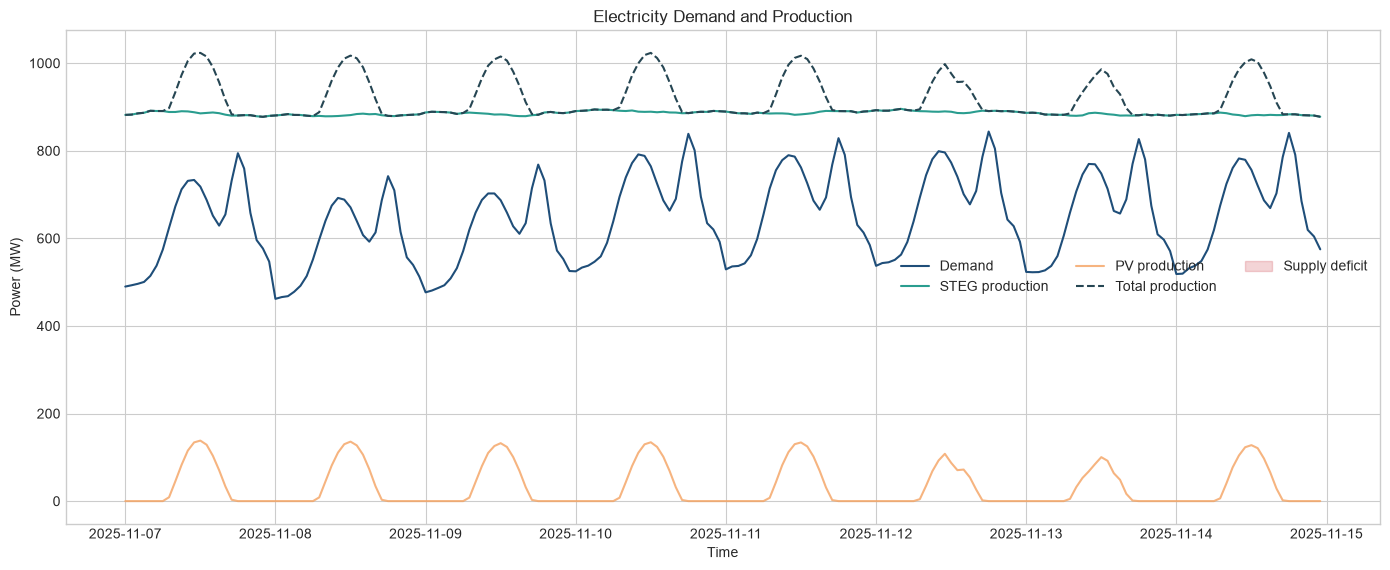

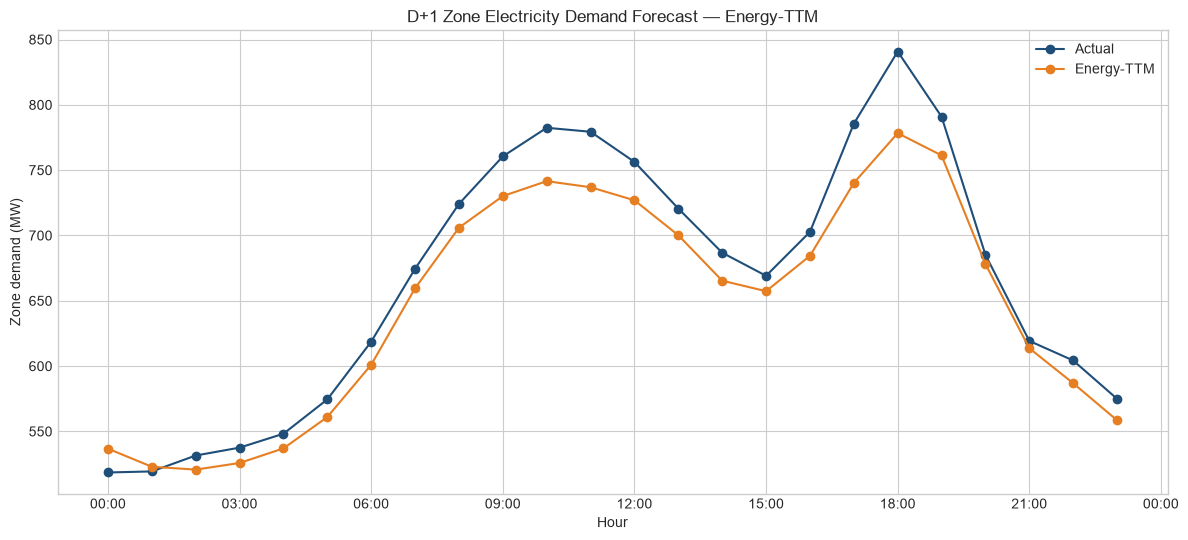

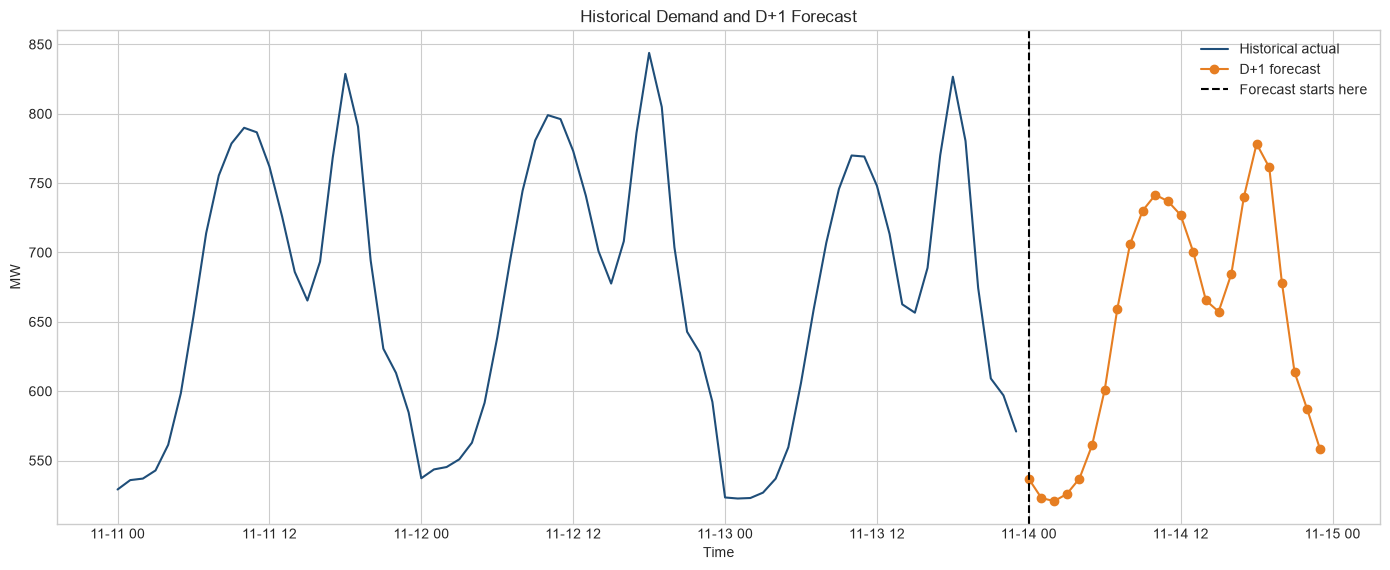

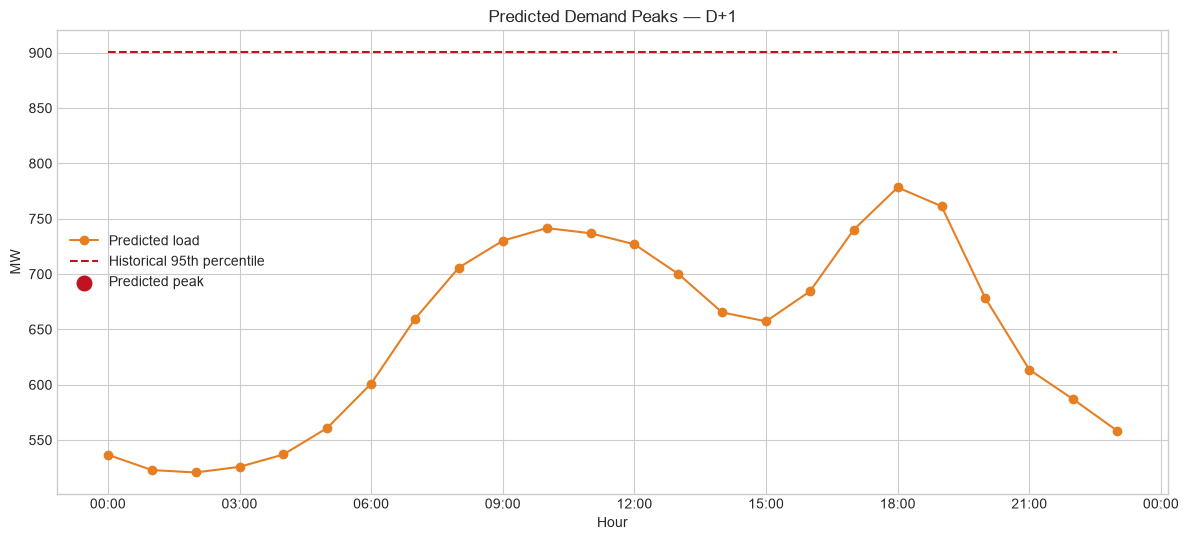

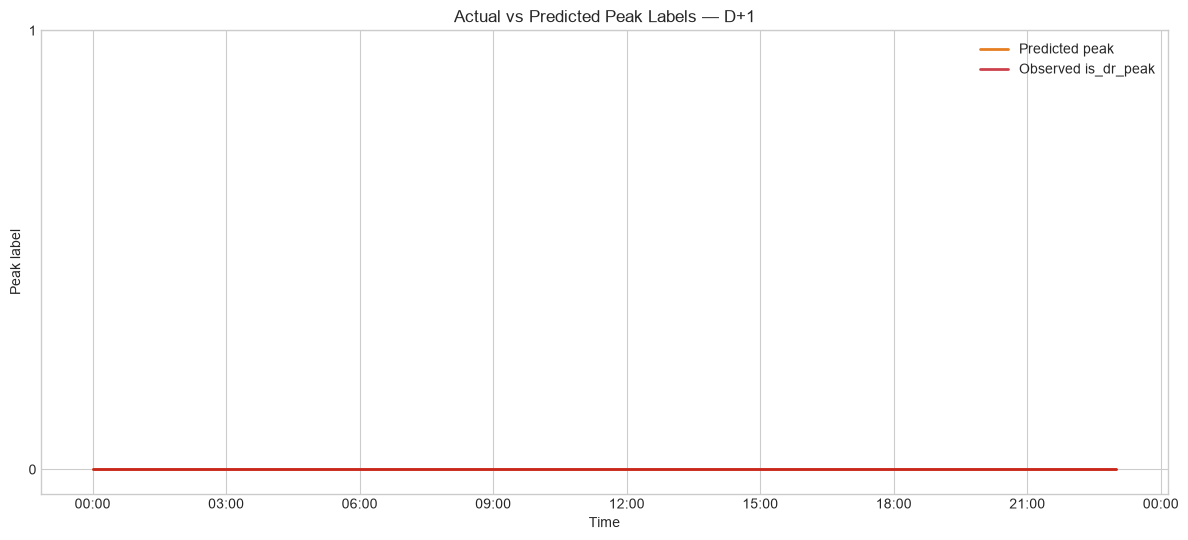

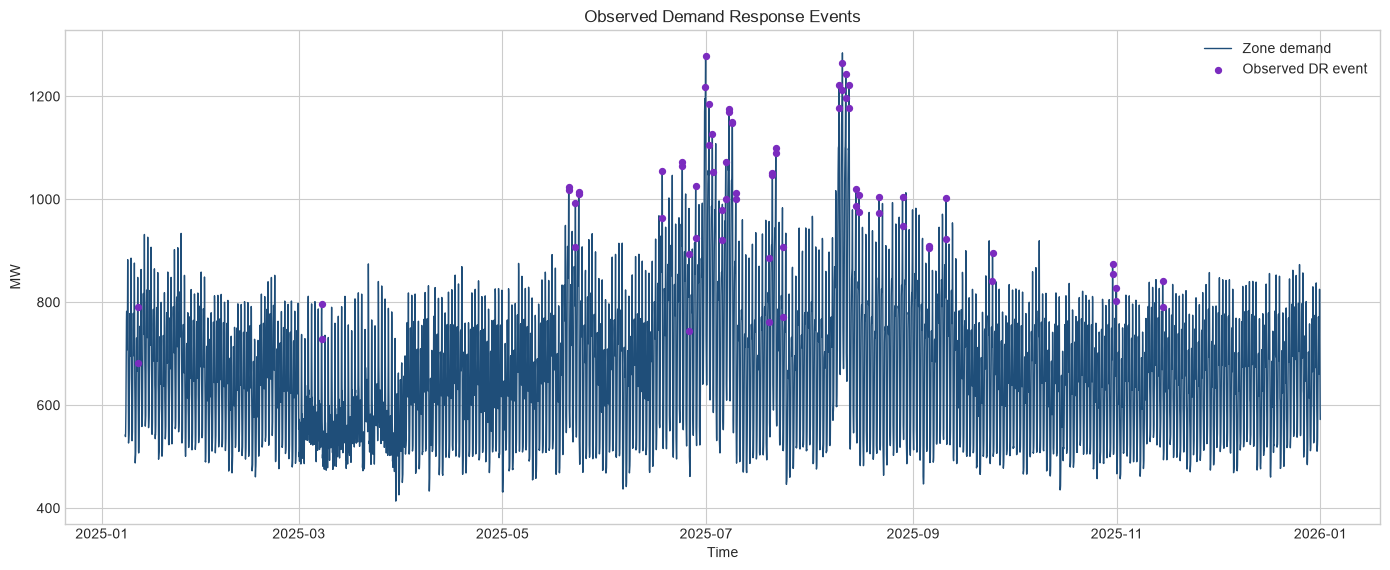

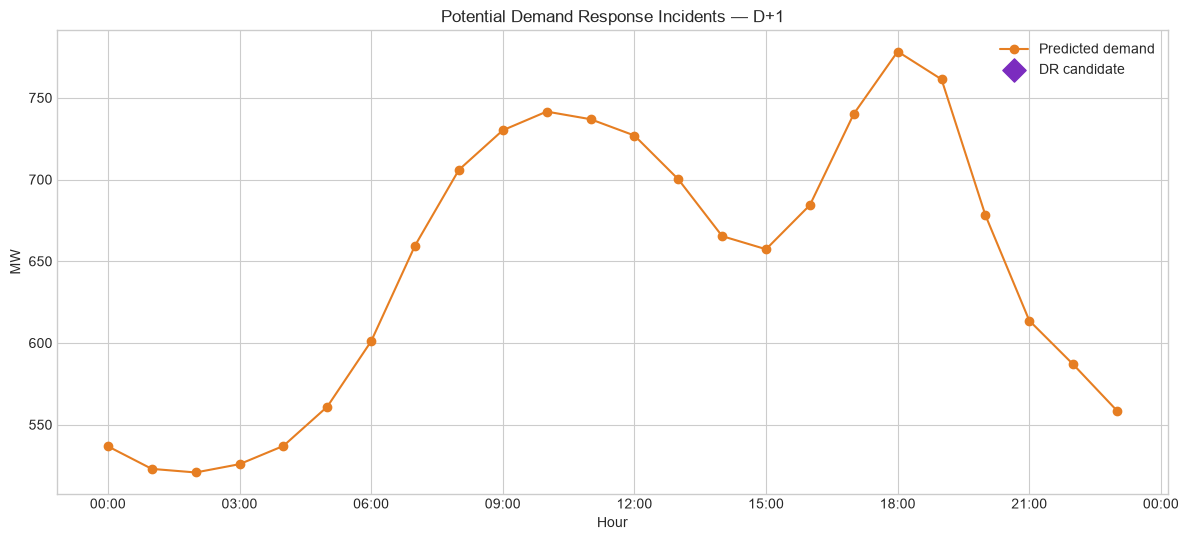

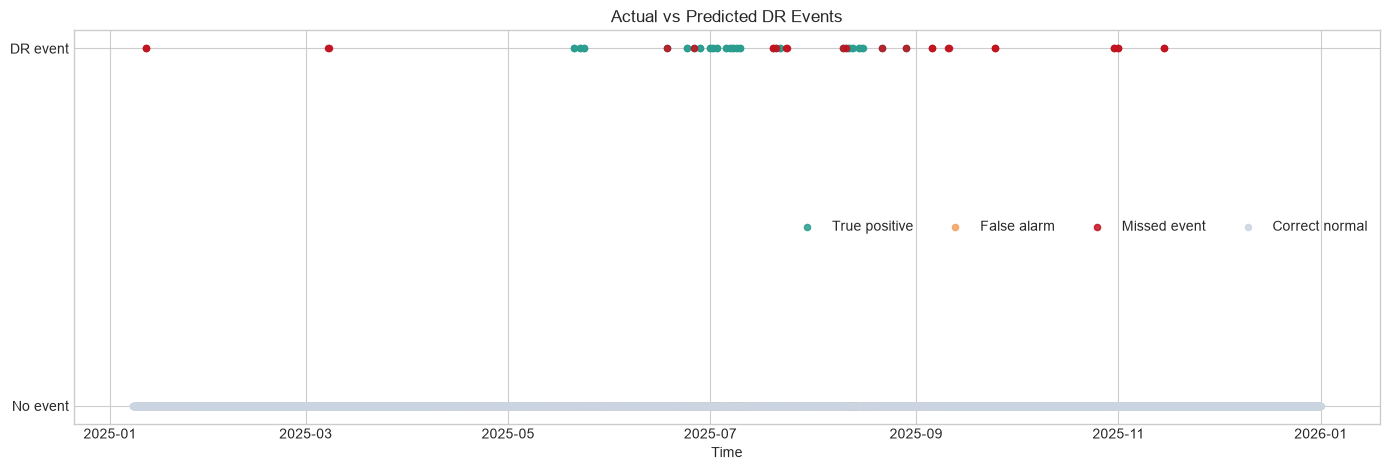

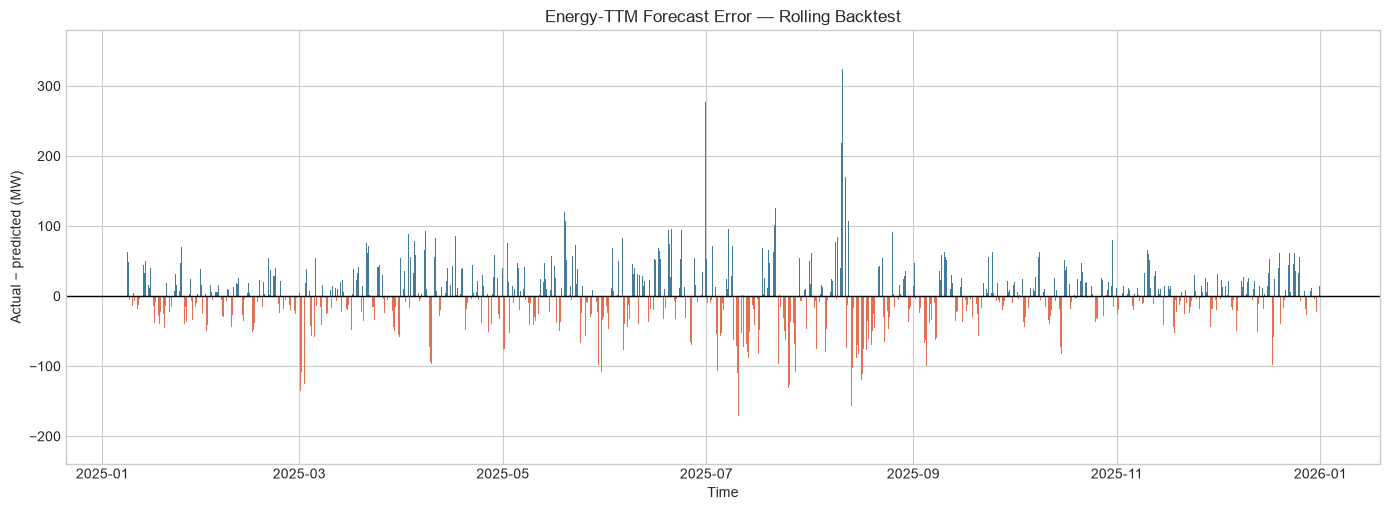

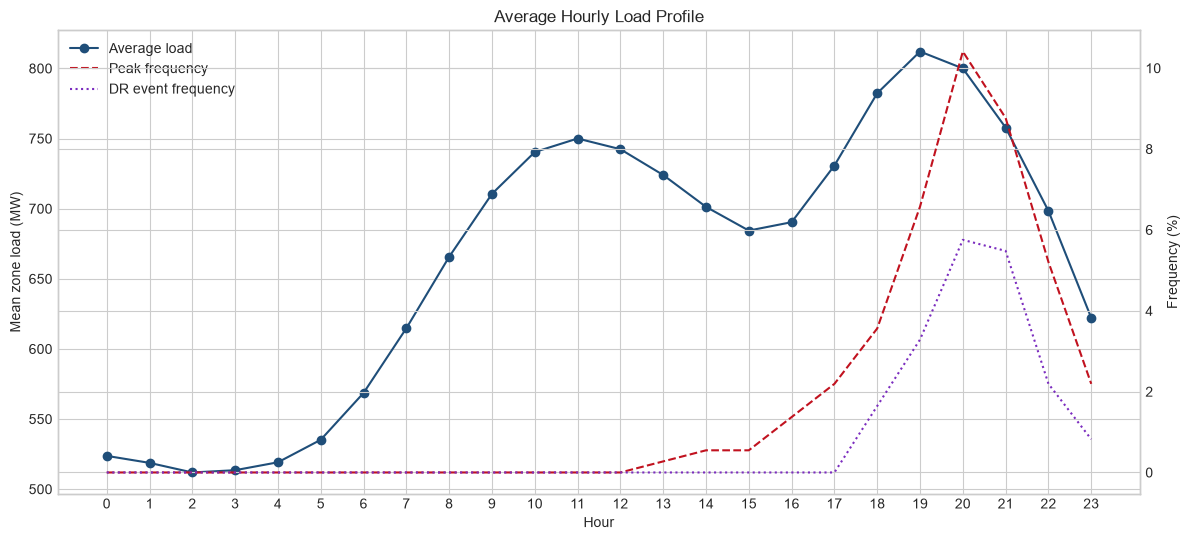

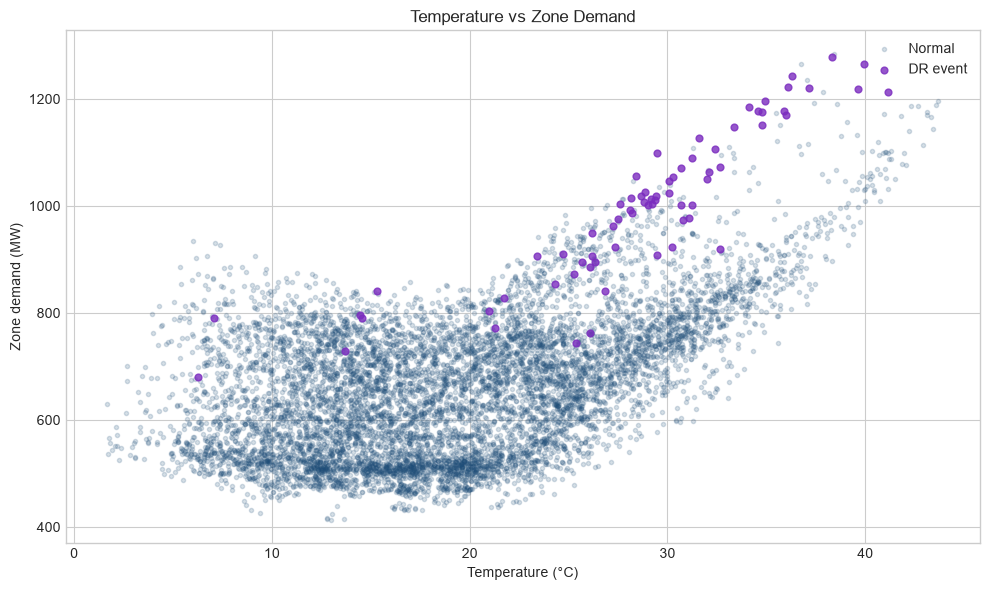

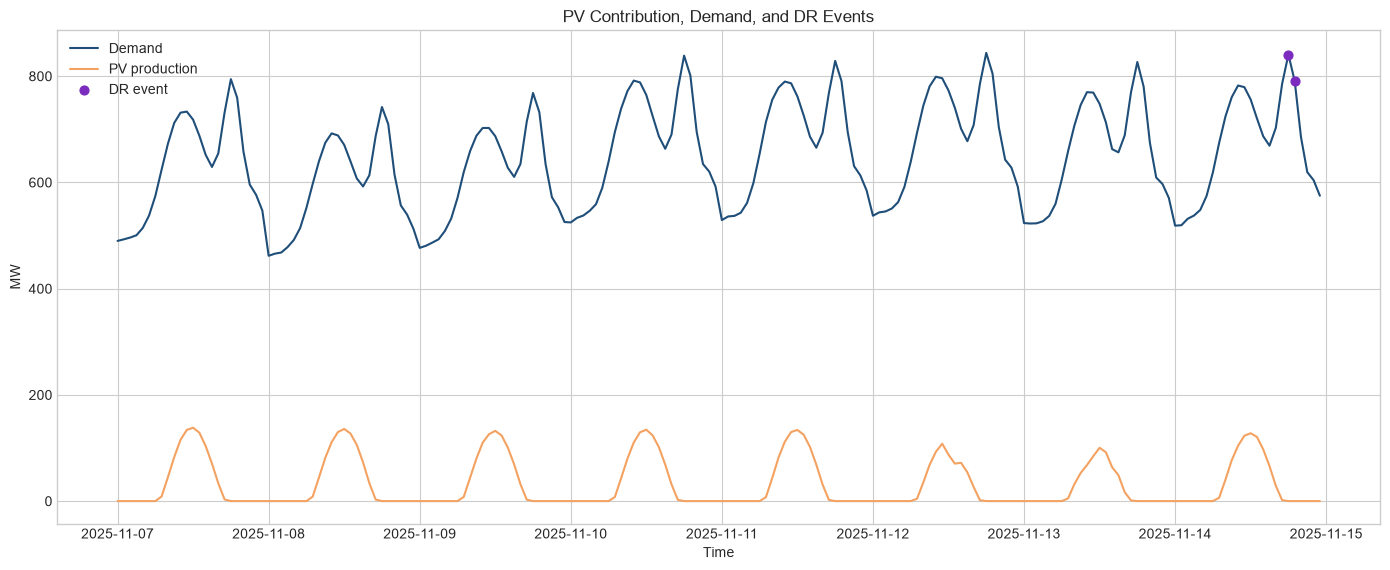

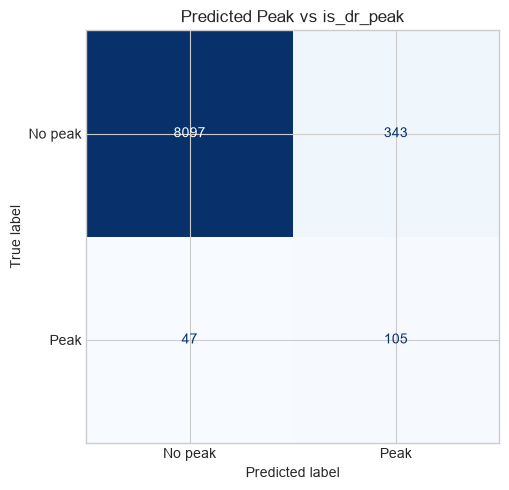

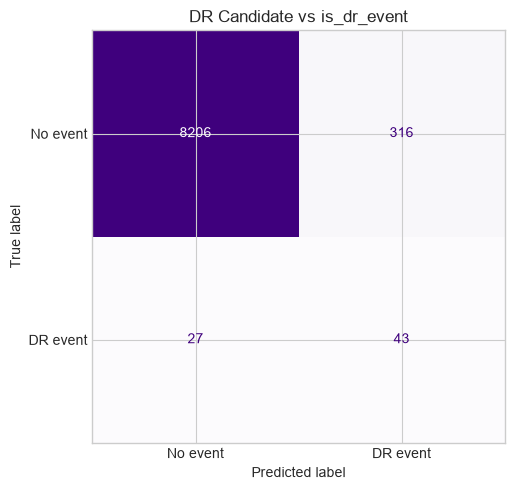

In [19]:
selected_day = presentation_day
selected = d1_forecast.copy()
window7 = hourly.loc[selected_day-pd.Timedelta(7,unit="D"):selected_day+pd.Timedelta(1,unit="D")-pd.Timedelta(1,unit="h")]

# Graph 3 — demand and production; deficits shaded
fig,ax=plt.subplots(figsize=(14,5.8)); ax.plot(window7.index,window7.zone_consumption_mw,label="Demand",color=COLORS["actual"])
ax.plot(window7.index,window7.steg_production_mw,label="STEG production",color=COLORS["production"])
ax.plot(window7.index,window7.pv_production_mw,label="PV production",color=COLORS["pv"],alpha=.8)
ax.plot(window7.index,window7.production_total_mw,label="Total production",color="#264653",linestyle="--")
deficit=window7.production_total_mw<window7.zone_consumption_mw
ax.fill_between(window7.index,window7.zone_consumption_mw,window7.production_total_mw,where=deficit,color=COLORS["peak"],alpha=.18,label="Supply deficit")
ax.set(title="Electricity Demand and Production",xlabel="Time",ylabel="Power (MW)"); ax.legend(ncol=3); save_show(fig,"demand_vs_production.png")

# Graph 4 — selected D+1
fig,ax=plt.subplots(figsize=FIGSIZE); ax.plot(selected.timestamp,selected.actual_zone_load_mw,marker="o",label="Actual",color=COLORS["actual"])
ax.plot(selected.timestamp,selected.predicted_zone_load_mw,marker="o",label="Energy-TTM",color=COLORS["pred"])
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M")); ax.set(title="D+1 Zone Electricity Demand Forecast — Energy-TTM",xlabel="Hour",ylabel="Zone demand (MW)"); ax.legend(); save_show(fig,"d1_forecast.png")

# Graph 5 — history plus forecast
hist72=hourly.loc[hourly.index<selected_day,"zone_consumption_mw"].tail(72)
fig,ax=plt.subplots(figsize=(14,5.8)); ax.plot(hist72.index,hist72,label="Historical actual",color=COLORS["actual"])
ax.plot(selected.timestamp,selected.predicted_zone_load_mw,marker="o",label="D+1 forecast",color=COLORS["pred"])
ax.axvline(selected_day,color="black",linestyle="--",label="Forecast starts here"); ax.set(title="Historical Demand and D+1 Forecast",xlabel="Time",ylabel="MW"); ax.legend(); save_show(fig,"history_plus_forecast.png")

# Graph 6 — predicted peaks
fig,ax=plt.subplots(figsize=FIGSIZE); ax.plot(selected.timestamp,selected.predicted_zone_load_mw,marker="o",color=COLORS["pred"],label="Predicted load")
ax.plot(selected.timestamp,selected.peak_threshold_mw,linestyle="--",color=COLORS["peak"],label="Historical 95th percentile")
m=selected.predicted_peak.eq(1); ax.scatter(selected.loc[m,"timestamp"],selected.loc[m,"predicted_zone_load_mw"],s=110,color=COLORS["peak"],label="Predicted peak",zorder=5)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M")); ax.set(title="Predicted Demand Peaks — D+1",xlabel="Hour",ylabel="MW"); ax.legend(); save_show(fig,"predicted_peaks.png")

# Graph 7 — actual and predicted peak labels
fig,ax=plt.subplots(figsize=FIGSIZE); ax.step(selected.timestamp,selected.predicted_peak,where="mid",label="Predicted peak",color=COLORS["pred"],linewidth=2)
ax.step(selected.timestamp,selected.actual_dr_peak,where="mid",label="Observed is_dr_peak",color=COLORS["peak"],linewidth=2,alpha=.8)
ax.set(yticks=[0,1],title="Actual vs Predicted Peak Labels — D+1",xlabel="Time",ylabel="Peak label"); ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M")); ax.legend(); save_show(fig,"actual_vs_predicted_peaks.png")

# Graph 8 — observed DR events in last 30 days
last30=hourly.loc[hourly.index>=backtest_days[0]]
fig,ax=plt.subplots(figsize=(14,5.8)); ax.plot(last30.index,last30.zone_consumption_mw,color=COLORS["actual"],linewidth=1,label="Zone demand")
events=last30.is_dr_event.eq(1); ax.scatter(last30.index[events],last30.loc[events,"zone_consumption_mw"],s=18,color=COLORS["event"],label="Observed DR event",zorder=4)
ax.set(title="Observed Demand Response Events",xlabel="Time",ylabel="MW"); ax.legend(); save_show(fig,"actual_dr_events.png")

# Graph 9 — predicted DR candidates selected day
fig,ax=plt.subplots(figsize=FIGSIZE); ax.plot(selected.timestamp,selected.predicted_zone_load_mw,marker="o",color=COLORS["pred"],label="Predicted demand")
c=selected.dr_candidate.eq(1); ax.scatter(selected.loc[c,"timestamp"],selected.loc[c,"predicted_zone_load_mw"],s=140,color=COLORS["event"],marker="D",label="DR candidate",zorder=5)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M")); ax.set(title="Potential Demand Response Incidents — D+1",xlabel="Hour",ylabel="MW"); ax.legend(); save_show(fig,"predicted_dr_candidates.png")

# Graph 10 — candidate/event outcomes over all backtest hours
fig,ax=plt.subplots(figsize=(14,4.8)); actual=backtest_results.actual_dr_event.to_numpy(); pred=backtest_results.dr_candidate.to_numpy()
outcome=np.where((actual==1)&(pred==1),"True positive",np.where((actual==0)&(pred==1),"False alarm",np.where((actual==1)&(pred==0),"Missed event","Correct normal")))
palette={"True positive":"#2A9D8F","False alarm":"#F4A261","Missed event":"#C1121F","Correct normal":"#CBD5E1"}
for name in palette:
    mask=outcome==name; ax.scatter(backtest_results.loc[mask,"timestamp"],np.where(actual[mask]==1,1,0),s=20,color=palette[name],label=name,alpha=.85)
ax.set(yticks=[0,1],yticklabels=["No event","DR event"],title="Actual vs Predicted DR Events",xlabel="Time"); ax.legend(ncol=4); save_show(fig,"dr_actual_vs_predicted.png")

# Graph 11 — forecast error
fig,ax=plt.subplots(figsize=(14,5.2)); ax.bar(backtest_results.timestamp,backtest_results.forecast_error_mw,width=.025,color=np.where(backtest_results.forecast_error_mw>=0,"#457B9D","#E76F51"))
ax.axhline(0,color="black",linewidth=1); ax.set(title="Energy-TTM Forecast Error — Rolling Backtest",xlabel="Time",ylabel="Actual − predicted (MW)"); save_show(fig,"forecast_error.png")

# Graph 12 — average hourly profile and label frequencies
profile=hourly.groupby("hour").agg(load=("zone_consumption_mw","mean"),peak_rate=("is_dr_peak","mean"),event_rate=("is_dr_event","mean"))
fig,ax=plt.subplots(figsize=FIGSIZE); ax.plot(profile.index,profile.load,marker="o",color=COLORS["actual"],label="Average load")
ax2=ax.twinx(); ax2.plot(profile.index,100*profile.peak_rate,color=COLORS["peak"],label="Peak frequency",linestyle="--"); ax2.plot(profile.index,100*profile.event_rate,color=COLORS["event"],label="DR event frequency",linestyle=":")
ax.set(title="Average Hourly Load Profile",xlabel="Hour",ylabel="Mean zone load (MW)",xticks=range(24)); ax2.set_ylabel("Frequency (%)"); lines=ax.lines+ax2.lines; ax.legend(lines,[l.get_label() for l in lines],loc="upper left"); save_show(fig,"hourly_load_profile.png")

# Graph 13 — temperature vs demand
fig,ax=plt.subplots(figsize=(10,6)); normal=hourly.is_dr_event.eq(0); event=hourly.is_dr_event.eq(1)
ax.scatter(hourly.loc[normal,"temperature_c"],hourly.loc[normal,"zone_consumption_mw"],s=9,alpha=.18,color=COLORS["actual"],label="Normal")
ax.scatter(hourly.loc[event,"temperature_c"],hourly.loc[event,"zone_consumption_mw"],s=24,alpha=.8,color=COLORS["event"],label="DR event")
ax.set(title="Temperature vs Zone Demand",xlabel="Temperature (°C)",ylabel="Zone demand (MW)"); ax.legend(); save_show(fig,"temperature_vs_demand.png")

# Graph 14 — PV, demand and DR events
fig,ax=plt.subplots(figsize=(14,5.8)); ax.plot(window7.index,window7.zone_consumption_mw,color=COLORS["actual"],label="Demand"); ax.plot(window7.index,window7.pv_production_mw,color=COLORS["pv"],label="PV production")
e=window7.is_dr_event.eq(1); ax.scatter(window7.index[e],window7.loc[e,"zone_consumption_mw"],color=COLORS["event"],s=40,label="DR event",zorder=4)
ax.set(title="PV Contribution, Demand, and DR Events",xlabel="Time",ylabel="MW"); ax.legend(); save_show(fig,"pv_contribution_dr_events.png")

# Confusion matrices
fig,ax=plt.subplots(figsize=(6,5)); ConfusionMatrixDisplay(peak_cm,display_labels=["No peak","Peak"]).plot(ax=ax,cmap="Blues",colorbar=False); ax.set_title("Predicted Peak vs is_dr_peak"); save_show(fig,"peak_confusion_matrix.png")
fig,ax=plt.subplots(figsize=(6,5)); ConfusionMatrixDisplay(dr_cm,display_labels=["No event","DR event"]).plot(ax=ax,cmap="Purples",colorbar=False); ax.set_title("DR Candidate vs is_dr_event"); save_show(fig,"dr_confusion_matrix.png")

## 20. Final results

In [20]:
final_columns=["timestamp","actual_zone_load_mw","predicted_zone_load_mw","forecast_error_mw","peak_threshold_mw","predicted_peak","actual_dr_peak","severity","dr_candidate","actual_dr_event"]
final_forecast=d1_forecast[final_columns].copy()
assert len(final_forecast)==24
display(final_forecast)

,timestamp,actual_zone_load_mw,predicted_zone_load_mw,forecast_error_mw,peak_threshold_mw,predicted_peak,actual_dr_peak,severity,dr_candidate,actual_dr_event
7440,2025-11-14 00:00:00,518.570000,536.757141,-18.187141,901.1165,0,0,Normal,0,0
7441,2025-11-14 01:00:00,519.368333,522.952820,-3.584486,901.1165,0,0,Normal,0,0
7442,2025-11-14 02:00:00,531.541667,520.755920,10.785746,901.1165,0,0,Normal,0,0
7443,2025-11-14 03:00:00,537.576667,525.835144,11.741523,901.1165,0,0,Normal,0,0
7444,2025-11-14 04:00:00,548.225000,537.000610,11.224390,901.1165,0,0,Normal,0,0
7445,2025-11-14 05:00:00,574.526667,561.016479,13.510187,901.1165,0,0,Normal,0,0
7446,2025-11-14 06:00:00,618.730000,601.041870,17.688130,901.1165,0,0,Normal,0,0
7447,2025-11-14 07:00:00,674.548333,659.591370,14.956964,901.1165,0,0,Normal,0,0
7448,2025-11-14 08:00:00,724.155000,705.947388,18.207612,901.1165,0,0,Normal,0,0
7449,2025-11-14 09:00:00,760.535000,730.139771,30.395229,901.1165,0,0,Normal,0,0


## 21. Summary

In [21]:
fm=forecast_metrics.loc["Energy-TTM"]; pm=peak_metrics.loc["Historical percentile"]
max_row=final_forecast.loc[final_forecast.predicted_zone_load_mw.idxmax()]
min_gap=float(d1_forecast.predicted_supply_demand_gap_mw.min())
print(f"""
=================================================
ENERGY-TTM + DEMAND RESPONSE ANALYSIS
=================================================

Dataset: {DATA_PATH.relative_to(PROJECT_ROOT)}
Raw resolution: 1 minute
Forecast resolution: 1 hour
Forecast horizon: 24 hours
Backtest period: {backtest_days[0].date()} to {backtest_days[-1].date()}

-------------------------------------------------
D+1 LOAD FORECAST (ROLLING BACKTEST)
-------------------------------------------------
MAE: {fm.MAE:.4f}
RMSE: {fm.RMSE:.4f}
MAPE: {fm.MAPE:.2f} %
R²: {fm.R2:.4f}
Persistence baseline MAE: {baseline_mae:.4f}
Energy-TTM improvement: {improvement_pct:.2f} %

-------------------------------------------------
PEAK DETECTION
-------------------------------------------------
Selected-day peak threshold: {final_forecast.peak_threshold_mw.iloc[0]:.4f} MW
Predicted peaks: {int(backtest_results.predicted_peak.sum())}
Actual peaks: {int(backtest_results.actual_dr_peak.sum())}
Precision: {pm.Precision:.4f}
Recall: {pm.Recall:.4f}
F1: {pm.F1:.4f}

-------------------------------------------------
DEMAND RESPONSE DETECTION
-------------------------------------------------
Predicted DR candidates: {int(backtest_results.dr_candidate.sum())}
Actual DR events: {int(backtest_results.actual_dr_event.sum())}
True positive: {tp}
False positive: {fp}
False negative: {fn}
Precision: {dr_metrics['Precision']:.4f}
Recall: {dr_metrics['Recall']:.4f}
F1: {dr_metrics['F1']:.4f}

-------------------------------------------------
GRID INFORMATION — SELECTED D+1
-------------------------------------------------
Maximum predicted load: {max_row.predicted_zone_load_mw:.4f} MW
Time of maximum predicted load: {max_row.timestamp:%Y-%m-%d %H:%M}
Minimum predicted supply-demand margin: {min_gap:.4f} MW (production uses lag-24 forecast)
Critical hours: {int(final_forecast.severity.eq('Critical').sum())}

=================================================
""")


ENERGY-TTM + DEMAND RESPONSE ANALYSIS

Dataset: data\dr_dataset_2025_1min_v2.csv
Raw resolution: 1 minute
Forecast resolution: 1 hour
Forecast horizon: 24 hours
Backtest period: 2025-01-08 to 2025-12-31

-------------------------------------------------
D+1 LOAD FORECAST (ROLLING BACKTEST)
-------------------------------------------------
MAE: 33.0500
RMSE: 47.6852
MAPE: 4.88 %
R²: 0.8677
Persistence baseline MAE: 31.0564
Energy-TTM improvement: -6.42 %

-------------------------------------------------
PEAK DETECTION
-------------------------------------------------
Selected-day peak threshold: 901.1165 MW
Predicted peaks: 448
Actual peaks: 152
Precision: 0.2344
Recall: 0.6908
F1: 0.3500

-------------------------------------------------
DEMAND RESPONSE DETECTION
-------------------------------------------------
Predicted DR candidates: 359
Actual DR events: 70
True positive: 43
False positive: 316
False negative: 27
Precision: 0.1198
Recall: 0.6143
F1: 0.2005

----------------------

## 22. Save outputs

In [22]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
hourly.reset_index().rename(columns={"index":"timestamp"}).to_csv(OUTPUT_DIR/"hourly_dataset.csv",index=False)
final_forecast.to_csv(OUTPUT_DIR/"d1_forecast.csv",index=False)
backtest_results.to_csv(OUTPUT_DIR/"backtest_results.csv",index=False)

metric_records=[]
for name,row in forecast_metrics.iterrows():
    for metric,value in row.items(): metric_records.append({"task":"forecast","method":name,"metric":metric,"value":value})
for name,row in peak_metrics.iterrows():
    for metric,value in row.items(): metric_records.append({"task":"peak_detection","method":name,"metric":metric,"value":value})
for metric,value in dr_metrics.items(): metric_records.append({"task":"dr_detection","method":"Interpretable rule","metric":metric,"value":value})
for metric,value in rf_metrics.items(): metric_records.append({"task":"dr_detection","method":"Random Forest","metric":metric,"value":value})
pd.DataFrame(metric_records).to_csv(OUTPUT_DIR/"model_metrics.csv",index=False)
backtest_results[["timestamp","dr_candidate","actual_dr_event","dr_risk_score","predicted_supply_demand_gap_mw"]].to_csv(OUTPUT_DIR/"dr_detection_results.csv",index=False)

required_outputs=["hourly_dataset.csv","d1_forecast.csv","backtest_results.csv","model_metrics.csv","dr_detection_results.csv",
"full_year_demand.png","household_vs_zone.png","demand_vs_production.png","d1_forecast.png","history_plus_forecast.png",
"predicted_peaks.png","actual_vs_predicted_peaks.png","actual_dr_events.png","predicted_dr_candidates.png",
"dr_actual_vs_predicted.png","forecast_error.png","hourly_load_profile.png","temperature_vs_demand.png",
"pv_contribution_dr_events.png","peak_confusion_matrix.png","dr_confusion_matrix.png"]
missing=[name for name in required_outputs if not (OUTPUT_DIR/name).exists()]
if missing: raise RuntimeError(f"Missing expected outputs: {missing}")
print(f"Saved and verified {len(required_outputs)} outputs in {OUTPUT_DIR.resolve()}")
for name in required_outputs: print(f"  {name}: {(OUTPUT_DIR/name).stat().st_size:,} bytes")

Saved and verified 21 outputs in C:\Users\moham\Desktop\demand response\demand_response_project\outputs
  hourly_dataset.csv: 3,123,488 bytes
  d1_forecast.csv: 2,470 bytes
  backtest_results.csv: 1,837,664 bytes
  model_metrics.csv: 1,547 bytes
  dr_detection_results.csv: 390,014 bytes
  full_year_demand.png: 415,534 bytes
  household_vs_zone.png: 594,717 bytes
  demand_vs_production.png: 368,081 bytes
  d1_forecast.png: 247,586 bytes
  history_plus_forecast.png: 294,036 bytes
  predicted_peaks.png: 163,562 bytes
  actual_vs_predicted_peaks.png: 74,321 bytes
  actual_dr_events.png: 749,240 bytes
  predicted_dr_candidates.png: 160,768 bytes
  dr_actual_vs_predicted.png: 90,727 bytes
  forecast_error.png: 96,182 bytes
  hourly_load_profile.png: 258,441 bytes
  temperature_vs_demand.png: 1,485,958 bytes
  pv_contribution_dr_events.png: 304,683 bytes
  peak_confusion_matrix.png: 51,662 bytes
  dr_confusion_matrix.png: 53,689 bytes


### Methodological note

Backtest labels and actual production are used only after forecasting for evaluation and
retrospective interpretation. The candidate rule uses predicted demand, lag-24 production,
historical thresholds/rates, and calendar-known flags. Results describe this dataset and should
be validated across other years and regions before operational use. All eligible 2025 days are
backtested so rare-event metrics are not reduced to an all-negative final-month test. The single
presentation day is the last labelled day and is illustrative; aggregate metrics use the full
rolling window.